In [54]:
import numpy as np
import matplotlib.pyplot as plt

### 1) static deflcection

In [34]:
# test: expectation


#estimated
dtheta = 0.0174533 # 0.1 deg in radians. estimated    # 1 --> 0.0174533
M = 2 # kg estimated
r1 = 0.02 #m
r2 = 0.04 #m
T0 = 720 #s --> 10min

#technical drawing
m = 0.028 #kg tech drawing
I = 62.915336055e-6 #kg m^2, using MIT estimated formula



# laser meas
L = 4.321 #m


#formula static deflection
c1 = m*M*L/r1**2
c2 = m*M*L/r2**2 

G = 4 * np.pi**2 * I / T0**2 * (dtheta)/(c1 - c2)  #units kg m^2 /s^2  * m^2/kg^2/m

print(G)

1.8431269648451874e-13


### first measurement

In [ ]:
# values
#technical drawing
m = 0.028 #kg tech drawing
I = 62.915336055e-6 #kg m^2, using MIT estimated formula

# laser meas
L = 4.321 #m

#measured:
M = 1.5  #kg +/-10g
r1 = 
r2 = 

#fit: T0, dtheta1, dtheta2

(3, 607)


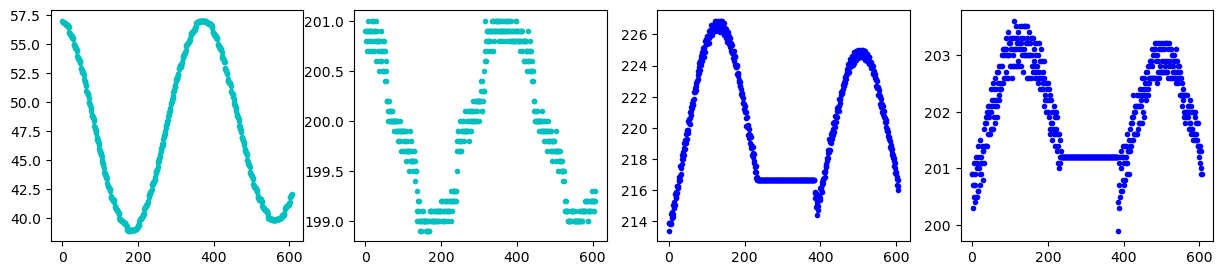

In [182]:
# import tracker data, calc in right plane. time order: pos2,pos1,zero pos: T0

pos2 = np.loadtxt(r'C:\Users\janbu\Desktop\FP_II\grav const\meas1\pos2_first_meas.txt', skiprows = 2, unpack=True)
pos1 = np.loadtxt(r'C:\Users\janbu\Desktop\FP_II\grav const\meas1\pos1_first_meas.txt', skiprows = 2, unpack=True)
print(pos2.shape) # t,x,y

plt.figure(figsize=(15,3))
plt.subplot(141)
plt.plot(pos1[0,:], pos1[1,:], 'c.')
plt.subplot(142)
plt.plot(pos1[0,:], pos1[2,:], 'c.')
plt.subplot(143)
plt.plot(pos2[0,:], np.sqrt(pos2[1,:]**2 + pos2[2,:]**2), 'b.')
plt.subplot(144)
plt.plot(pos2[0,:], pos2[2,:], 'b.')


In [184]:
pos1_fft = np.fft.fft(pos1[1,:])

[]

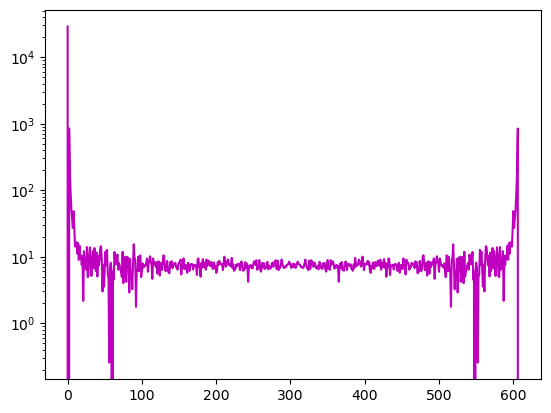

In [187]:
plt.plot( pos1_fft, 'm')
plt.semilogy()

In [62]:
# curve fitting
from scipy.optimize import curve_fit

In [172]:
#free param: damping tau,  freq w
def theta(t,A,tau,w, phase,h):
    return A * np.exp(-t/tau) * np.sin(w*t + phase) + h     # maybe include height/y
#def theta(t,A,w, phase,h):
#    return A * np.sin(w*t + phase) + h 
#fit
#popt, pcov = curve_fit( fit-function, x_data, y_data, p0= initial guess for
p0 = [0.1, 5, 0.02, 0,200]


popt, pcov = curve_fit( theta, pos1[0,:], pos1[1,:], p0= p0)
perr = np.sqrt(np.diag(pcov))

In [173]:
print(popt)
print(pcov)
#omega
print(2*np.pi/popt[2])
chi2 = np.sum((pos1[1,:]- theta(pos1[0,:], *popt))**2 / theta(pos1[0,:], *popt))
print(chi2)

[-9.35182019e+00  5.26395656e+03  1.63924375e-02 -1.38252369e+00
  4.81478442e+01]
[[ 4.43813781e-04  3.17573163e+00  2.76871745e-08 -9.78484422e-06
   9.80064566e-06]
 [ 3.17573163e+00  3.04029164e+04  1.89028287e-04 -6.32371137e-02
   1.95818863e-01]
 [ 2.76871745e-08  1.89028287e-04  5.00095006e-11 -1.39816640e-08
  -3.81983637e-09]
 [-9.78484422e-06 -6.32371137e-02 -1.39816640e-08  5.31773077e-06
   3.25758259e-06]
 [ 9.80064566e-06  1.95818863e-01 -3.81983637e-09  3.25758259e-06
   5.58326790e-05]]
383.29780457206
0.3923574903312601


In [164]:
#fit2
#popt, pcov = curve_fit( fit-function, x_data, y_data, p0= initial guess for
p0 = [*popt]


popt2, pcov2 = curve_fit( theta, pos2[0,:], pos2[1,:] , p0= p0)
perr2 = np.sqrt(np.diag(pcov2))

print(popt2)
chi2 = np.sum(( pos2[1,:] - theta(pos2[0,:], *popt2))**2 / theta(pos2[0,:], *popt2))
print(chi2)

[ 1.05231168e+01 -1.77620889e+10  1.72425726e-02 -7.96644302e-01
  8.60574235e+01]
61.686728807272125


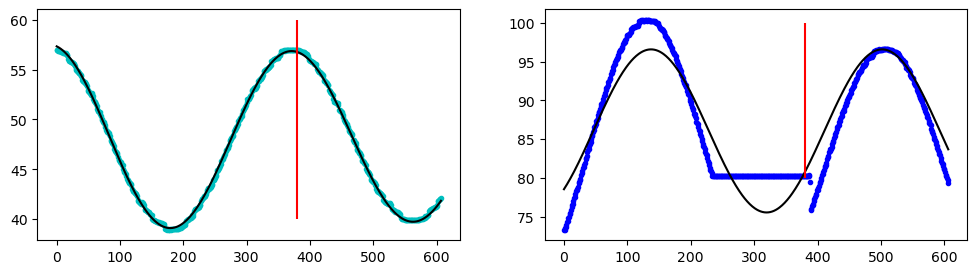

In [165]:
#check fit 
cut = 380
plt.figure(figsize=(12,3))
plt.subplot(121)
plt.plot(pos1[0,:], pos1[1,:], 'c.')
plt.plot(pos1[0,:], theta(pos1[0,:],*popt), 'k')
plt.vlines(cut, 40,60, 'r')
plt.subplot(122)
plt.plot(pos2[0,:], pos2[1,:], 'b.')
plt.plot(pos2[0,:], theta(pos2[0,:],*popt2), 'k')
plt.vlines(cut, 80,100, 'r')

In [130]:
#crude conversion
#WE NEED A WAYYYY BETTER METHOD TO CONVERT TO TRACKER UNITS TO m 
print('1 step in tracker =', 62/328.8 ,'cm')
print(abs(np.mean(pos1[1,:cut]) - np.mean(pos2[1,:cut]))*62/328.8, '= dist equil pos 1 and 2 in cm')
print('dtheta', np.arctan( (abs(np.mean(pos1[1,:390]) - np.mean(pos2[1,:390]))*62/328.8)*0.01 / 4.321))
print('T approx {}s '.format(cut) )

1 step in tracker = 0.18856447688564476 cm
7.3345676463055405 = dist equil pos 1 and 2 in cm
dtheta 0.016793694158146938
T approx 380s 


In [203]:
#first meas

# values
#technical drawing
m = 0.028 #kg tech drawing
I = 62.915336055e-6 #kg m^2, using MIT estimated formula

# laser meas
L = 4.321 #m

#measured:
M = 1.5  #kg +/-10g

r1 = 0.057 #m
r2 = 0.087 #m

#fit: T0, dtheta1, dtheta2
T0 = 2*np.pi/popt[2]
dtheta = 0.016793694158146938

#formula static deflection
delta = 0.002 #m
c1 = m*M*L/(r1-delta)**2
c2 = m*M*L/(r2+delta)**2 

G = 4 * np.pi**2 * I / T0**2 * (dtheta)/(c1 - c2)  #units kg m^2 /s^2  * m^2/kg^2/m

print(G)

7.656323231631898e-12


In [ ]:
# from this calc T0 (or zero pos), dtheta (for pos 1 and 2)

## 17.3. meas2

In [225]:
#import
pos1_1 = np.loadtxt(r'C:\Users\janbu\Desktop\FP_II\grav const\meas2\dat_pos1_1.txt', skiprows = 2, unpack=True)
pos2_1 = np.loadtxt(r'C:\Users\janbu\Desktop\FP_II\grav const\meas2\dat_pos2_1.txt', skiprows = 2, unpack=True)
pos1_2 = np.loadtxt(r'C:\Users\janbu\Desktop\FP_II\grav const\meas2\dat_pos1_2.txt', skiprows = 2, unpack=True)
pos2_2 = np.loadtxt(r'C:\Users\janbu\Desktop\FP_II\grav const\meas2\dat_pos2_2.txt', skiprows = 2, unpack=True)
zero = np.loadtxt(r'C:\Users\janbu\Desktop\FP_II\grav const\meas2\zero.txt', skiprows = 2, unpack=True)

In [351]:
pos2_2 = np.loadtxt('./meas2/dat_pos2_2.txt', skiprows = 2, unpack=True)
print(pos2_2.shape)

(3, 1866)


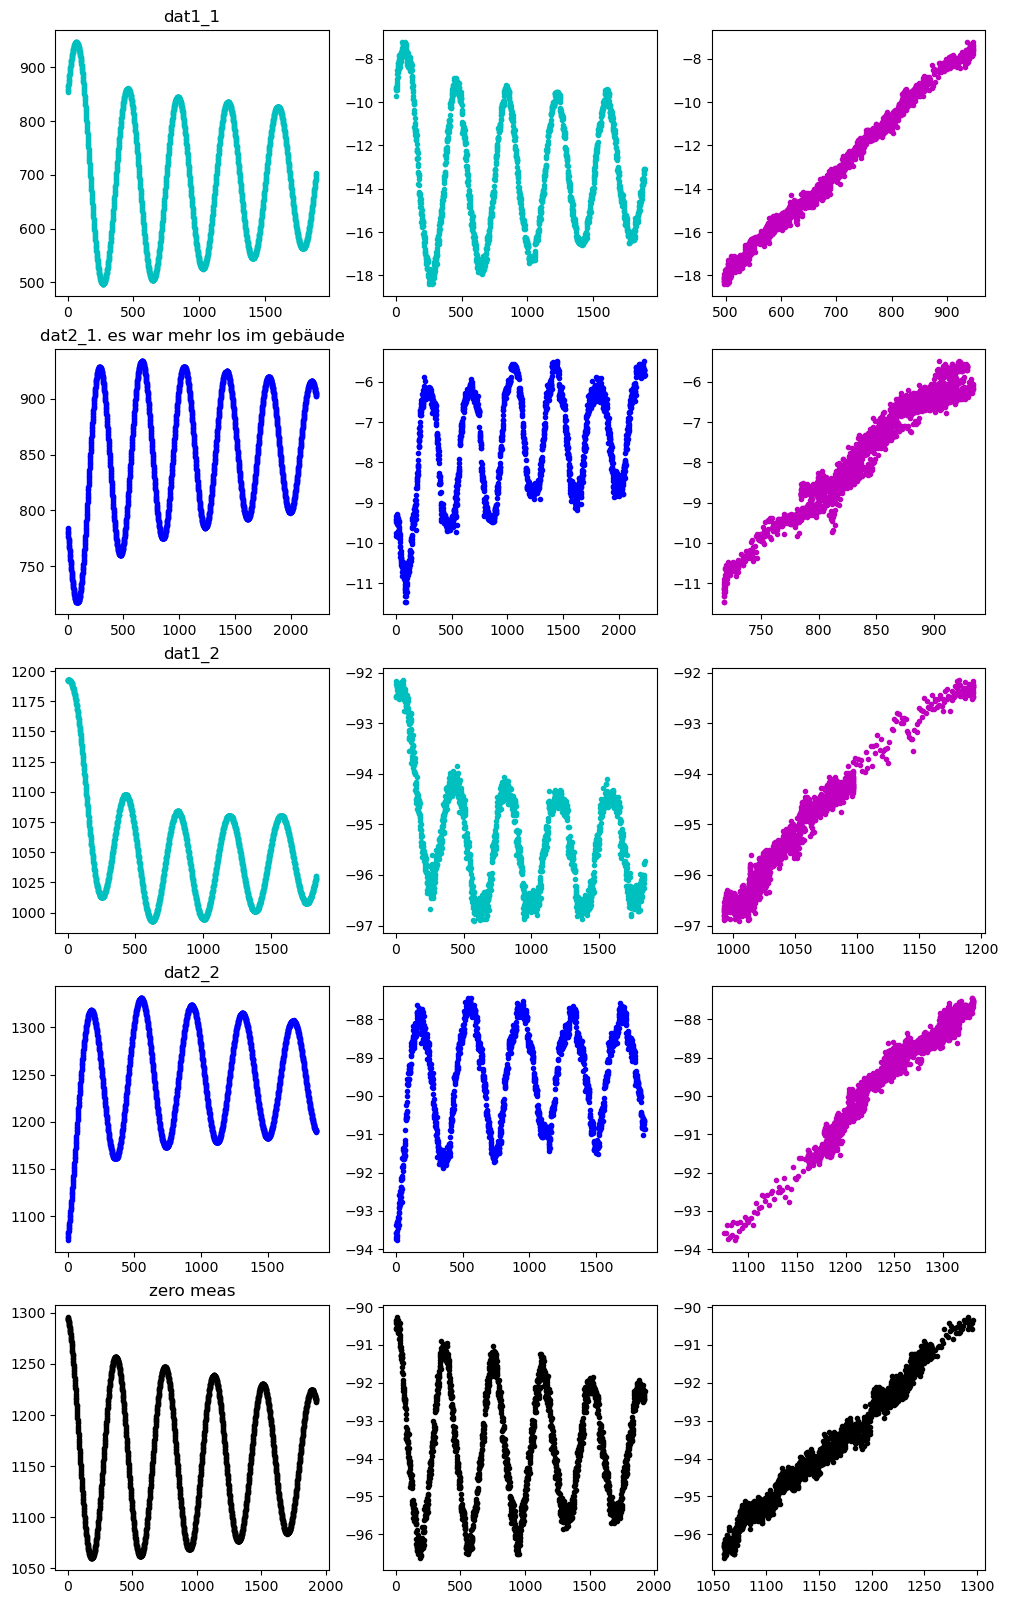

In [230]:
plt.figure(figsize=(12,20))
x=5
y=3
plt.subplot(x,y,1)
plt.title('dat1_1')
plt.plot(pos1_1[0,:],pos1_1[1,:], 'c.')
plt.subplot(x,y,2)
plt.plot(pos1_1[0,:], pos1_1[2,:], 'c.')
#plt.plot(pos1_1[0,:], pos1_1[2,:], 'c.')
plt.subplot(x,y,3)
plt.plot(pos1_1[1,:], pos1_1[2,:], 'm.')
plt.subplot(x,y,4)
plt.title('dat2_1. es war mehr los im gebäude')
plt.plot(pos2_1[0,:], pos2_1[1,:], 'b.')
plt.subplot(x,y,5)
plt.plot(pos2_1[0,:], pos2_1[2,:], 'b.')
plt.subplot(x,y,6)
plt.plot(pos2_1[1,:], pos2_1[2,:], 'm.')
plt.subplot(x,y,7)
plt.title('dat1_2')
plt.plot(pos1_2[0,:], pos1_2[1,:], 'c.')
plt.subplot(x,y,8)
plt.plot(pos1_2[0,:], pos1_2[2,:], 'c.')
plt.subplot(x,y,9)
plt.plot(pos1_2[1,:], pos1_2[2,:], 'm.')
plt.subplot(x,y,10)
plt.title('dat2_2')
plt.plot(pos2_2[0,:], pos2_2[1,:], 'b.')
plt.subplot(x,y,11)
plt.plot(pos2_2[0,:], pos2_2[2,:], 'b.')
plt.subplot(x,y,12)
plt.plot(pos2_2[1,:], pos2_2[2,:], 'm.')
plt.subplot(x,y,13)
plt.title('zero meas')
plt.plot(zero[0,:], zero[1,:], 'k.')
plt.subplot(x,y,14)
plt.plot(zero[0,:], zero[2,:], 'k.')
plt.subplot(x,y,15)
plt.plot(zero[1,:], zero[2,:], 'k.')

[[1.         0.99605202]
 [0.99605202 1.        ]]


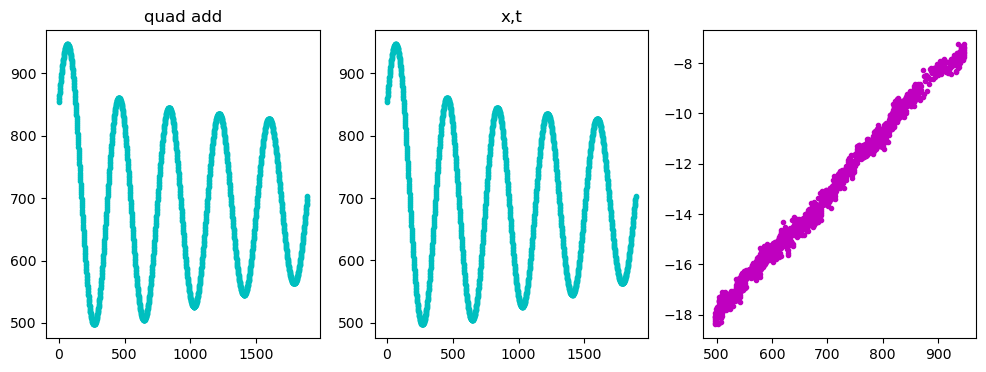

In [349]:
x=1
y=3
plt.figure(figsize=(12,4))
plt.subplot(x,y,1)
plt.title('quad add')
plt.plot(pos1_1[0,:], np.sqrt(pos1_1[1,:]**2 + pos1_1[2,:]**2 ), 'c.')
plt.subplot(x,y,2)
plt.title('x,t')
plt.plot(pos1_1[0,:], pos1_1[1,:], 'c.')
#plt.plot(pos1_1[0,:], pos1_1[2,:], 'c.')
plt.subplot(x,y,3)
plt.plot(pos1_1[1,:], pos1_1[2,:], 'm.')

print(np.corrcoef(pos1_1[1,:], pos1_1[2,:]))

In [425]:
# write pipeline for fit, corr

#TO DO: errors, from fits!!!

from scipy.optimize import curve_fit

def fit(dat_x, dat_y, dat_t):
    print('::haaalloo::')
    print('::using given initial guesses::')
    p0_lin = [0.01,-10]

    p0_osci = [180, 2000, 0.017, -1.5, 630]
    
    print(p0_lin, 'linear fit')
    print(p0_osci, 'damped oscillator fit')
    print()
    
    #free param: damping tau,  freq w
    def theta(t,A,tau,w, phase,h):
        return A * np.exp(-t/tau) * np.sin(w*t + phase) + h     # maybe include height/y

    def lin(x,a,b):
        return a*x + b
    
    #first we want to correct shift, with x-y-correlation
    print('::start: linear fit correlation::')   
    
    poptlin, pcovlin = curve_fit( lin, dat_x, dat_y, p0= p0_lin)
    perrlin = np.sqrt(np.diag(pcovlin))
    
    chi2lin = np.sum(( dat_y - lin(dat_x, *poptlin))**2 /dat_y)
    print('done: chi2_linear={}'.format(chi2lin))
    plt.figure(figsize=(6,3))
    plt.subplot(121)
    plt.title('linfit')
    plt.plot(dat_x, dat_y, 'k')
    plt.plot(dat_x, lin(dat_x,*poptlin), 'r')
    print()
    print('::changing xdata::')
    dat_x_new = dat_x - poptlin[0]*dat_x+poptlin[1]
    print()
    print('::fitting oscillator::')

    popt, pcov = curve_fit( theta, dat_t, dat_x_new, p0= p0_osci)
    perr = np.sqrt(np.diag(pcov))

    chi2 = np.sum(( dat_x_new - theta(dat_t, *popt))**2/dat_x_new)
    print('done: chi2={}'.format(chi2))
    plt.subplot(122)
    plt.title('damped oscillator')
    plt.plot(dat_t, dat_x_new, 'c.')
    plt.plot(dat_t, theta(dat_t,*popt), 'k')
    
    T = 2*np.pi/popt[2] #period
    theta = np.mean(theta(dat_t, *popt)) #this needs a conversion
    
    print('::results::')
    print('all parameters A,tau,w, phase,h',popt)
    print()
    print('T={}s'.format(T))
    print('equil pos theta={} UNIT ??'.format(theta))

In [344]:
# write pipeline for fit, corr

#TO DO: errors, from fits!!!

from scipy.optimize import curve_fit

def fit_r(dat_x, dat_y, dat_t):

    print('::haaalloo::')
    print('::using given initial guesses::')

    p0_osci = [180, 4000, 0.017, -1.5, 630]
    

    
    #free param: damping tau,  freq w
    def theta(t,A,tau,w, phase,h):
        return A * np.exp(-t/tau) * np.sin(w*t + phase) + h     # maybe include height/y


    print('::fitting oscillator::')
    
    dat_x_new = np.sqrt(dat_x**2 + dat_y**2)

    popt, pcov = curve_fit( theta, dat_t, dat_x_new, p0= p0_osci)
    perr = np.sqrt(np.diag(pcov))

    chi2 = np.sum(( dat_x_new - theta(dat_t, *popt))**2/dat_x_new)
    print('done: chi2={}'.format(chi2))
    plt.subplot(122)
    plt.title('damped oscillator')
    plt.plot(dat_t, dat_x_new, 'c.')
    plt.plot(dat_t, theta(dat_t,*popt), 'k')
    
    T = 2*np.pi/popt[2] #period
    theta = np.mean(theta(dat_t, *popt)) #this needs a conversion
    
    print('::results::')
    print('all parameters A,tau,w, phase,h',popt)
    print()
    print('T={}s'.format(T))
    print('equil pos theta={} UNIT ??'.format(theta))

::haaalloo::
::using given initial guesses::
::fitting oscillator::
done: chi2=42.96223740171285
::results::
all parameters A,tau,w, phase,h [2.13373799e+02 3.41890077e+03 1.65464980e-02 2.48886903e-01
 6.84840531e+02]

T=379.72900930523156s
equil pos theta=672.8548533964607 UNIT ??


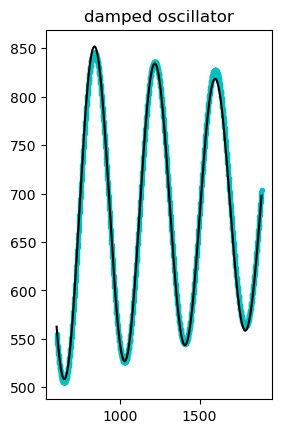

In [419]:
fit_r(pos1_1[1,600:], pos1_1[2,600:], pos1_1[0,600:])

::haaalloo::
::using given initial guesses::
::fitting oscillator::
done: chi2=8.620706848063335
::results::
all parameters A,tau,w, phase,h [-9.25889922e+01  4.63981644e+03  1.65499760e-02  3.73472627e-03
  8.56219857e+02]

T=379.64920987465297s
equil pos theta=860.3246140600842 UNIT ??


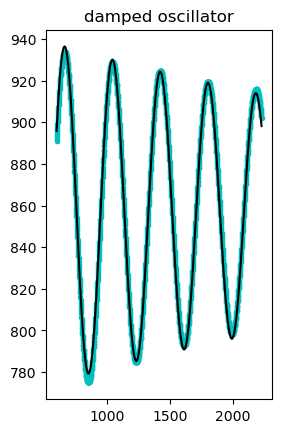

In [420]:
fit_r(pos2_1[1,600:], pos2_1[2,600:], pos2_1[0,600:])

In [466]:
# values
#technical drawing
m = 0.028 #kg tech drawing
I = 62.915336055e-6 #kg m^2, using MIT estimated formula

# laser meas
L = 4.321 #m
l=0.429

#measured:
M = 1.5  #kg +/-10g

r1 = 0.051722 #m  51.722+/-0.011
r2 = 0.052152 #m  52.152+/-0.011


#fit: T0, dtheta1, dtheta2
theta1=672.8548533964607*0.0586 #conversion factor for vid setup 1 in cm/'m'
theta2=860.3246140600842*0.0586
dtheta= 2*np.arctan( (0.5*abs(theta1 - theta2))*0.01 / 4.321)  #0.01 go from cm to m
dtheta0= np.arctan( (abs(theta1 - theta2))*0.01 / 4.321) #wrong formula, but only 1e-6 error
#print(dtheta - dtheta0)
T = unp.uarray(379.9587037978669, 0.005) # mean of both, in principle we have zero measurement for full glory

#formula static deflection
delta = 0.00 #m
#print(r1+delta, r2-delta)
#c1 = m*M*L*(1/(r1+delta)**2 + 1/(r2-delta)**2)
#c2 = m*M*L*(1/(r1-delta)**2 + 1/(r2+delta)**2) 
#r = (r1+r2)/2
c1 = 2*m*M*l/(r1)**2   #FACTORRRR 2 ????????
c2 = -2*m*M*l/(r2)**2 

G = 4 * np.pi**2 * I / T**2 * (dtheta)/(c1 - c2)  #units kg m^2 /s^2  * m^2/kg^2/m

print(G)




(1.63693+/-0.00004)e-11


In [446]:
#alternative follow MIT
r = (r1+r2)/2
l=0.429
G = r**2 * l /(8 * M) * (2*np.pi/T)**2 * dtheta
G

6.70405998113839e-10

::haaalloo::
::using given initial guesses::
::fitting oscillator::
done: chi2=15.570003794548278
::results::
all parameters A,tau,w, phase,h [-4.06231182e+01 -7.01101769e+10  1.65138463e-02 -2.47355779e+00
  1.04472596e+03]

T=380.47982141717466s
equil pos theta=1042.074833852749 UNIT ??
::haaalloo::
::using given initial guesses::
::fitting oscillator::
done: chi2=2.170398251300382
::results::
all parameters A,tau,w, phase,h [ 9.16416459e+01  4.09404036e+03  1.65567464e-02 -1.27710429e+00
  1.25162848e+03]

T=379.4939625654313s
equil pos theta=1249.6597283089984 UNIT ??


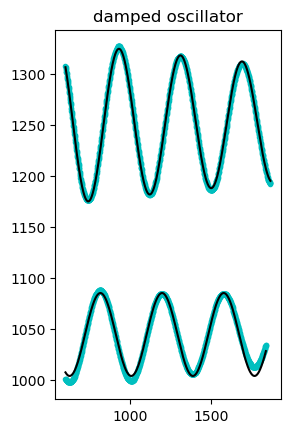

In [447]:
# use second run
fit_r(pos1_2[1,600:], pos1_2[2,600:], pos1_2[0,600:])
fit_r(pos2_2[1,600:], pos2_2[2,600:], pos2_2[0,600:])

::haaalloo::
::using given initial guesses::
::fitting oscillator::
done: chi2=2.842184057252404
::results::
all parameters A,tau,w, phase,h [-1.08406067e+02  4.07077452e+03  1.65364953e-02 -1.45998517e+00
  1.15983846e+03]

T=379.9587037978669s
equil pos theta=1161.955266143335 UNIT ??


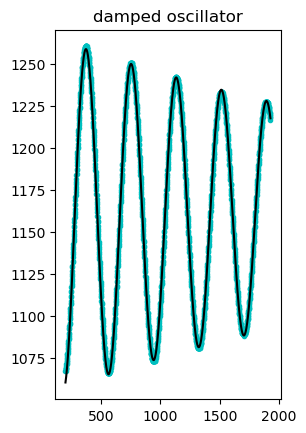

In [317]:
fit_r(zero[1,200:], zero[2,200:], zero[0,200:])

In [454]:
!pip install uncertainties

In [455]:
from uncertainties import unumpy as unp

In [463]:
arr = unp.uarray(1, 0.01)
print(arr)
print(unp.nominal_values(arr))
print(unp.std_devs(arr))

1.000+/-0.010
1.0
0.01


In [464]:
m = unp.uarray(0.028, 0)  #0.028 #kg tech drawing
l=unp.uarray(0.429, 0.001) #uncert tech drawing
I = m*l**2/2
print(unp.nominal_values(I))
print(unp.std_devs(I))

0.002576574
1.2012e-05


In [542]:
# calculate G , incl uncertainties
def G(theta1, theta2, T, conversion_factor):
    #technical drawing
    m = unp.uarray(0.028, 0)  #0.028 #kg tech drawing
    l=unp.uarray(0.0429, 0.001) #uncert tech drawing
    I = m*l**2/2 #kg m^2, using MIT estimated formula
    
    # laser meas
    L =  unp.uarray(4.321, 0.001) #m
        
    #measured:
    M = unp.uarray(1.5,0.01)  #kg +/-10g
    
    r1 = unp.uarray(0.051722,0.00011) #m  51.722+/-0.011
    r2 = unp.uarray(0.052152,0.00011) #m  52.152+/-0.011
        
    #fit: T0, dtheta1, dtheta2
    h1=theta1*conversion_factor #conversion factor for vid setup 1 in cm/'m'. used squared addition here
    h2=theta2*conversion_factor
    
    #dtheta= unp.arctan( (theta2 - theta1)*0.01 / 4.321) #0.01 go from cm to m
    dtheta= 2*unp.arctan( (0.5*(h2 - h1))*0.01 / 4.321) #0.01 go from cm to m
    #T = unp.uarray(379.9587037978669, 0) # mean of both, in principle we have zero measurement for full glory
    
    #formula static deflection
    delta = 0.002 #m
    c1 = m*M*l/(r1)**2
    c2 = -m*M*l/(r2)**2 
    
    G = 4 * np.pi**2 * I / T**2 * (dtheta)/(c1 - c2)  #units kg m^2 /s^2  * m^2/kg^2/m
    
    return G

In [543]:
T = unp.uarray(379.9587037978669, 0) # mean of both, in principle we have zero measurement for full glory
#fit: T0, dtheta1, dtheta2
theta1=unp.uarray(1042.074833852749, 0 ) #conversion factor for vid setup 1 in cm/'m'. used squared addition here
theta2=unp.uarray(1249.6597283089984, 0)
conversion_factor = 0.0655
print(G(theta1,theta2,T, 0.0655))

(1.66+/-0.04)e-10
